# From fitting a trajectory to fitting a transition function - Linear 2D

In [1]:
%loadlibs
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
from scipy.integrate import solve_ivp
torch.set_default_device('mps')

Loaded libraries:
	- numpy (np)
	- matplotlib.pyplot (plt)
	- torch
	- torch.nn (nn)
	- torch.optim (optim)
	- tqdm


Training a PINN for learning a dynamical system 
$$\dot{x}(t) = f(x(t))$$
consists in learning a transition function
$$x(t) = \phi(t, t_0, x(t_0)),$$
where $x(t)$ is a solution of the first equation. To do so, classically, in the literature, one trains a MLP $f^{\text{NN}}(x)$ such that
$$\dot{f^{\text{NN}}} = f,$$
or
$$\frac{\partial f^{\text{NN}}}{\partial t} = f.$$
However, additional constraint can usually be inferred from the initial system:
- Consistency: $\phi(t, t, x(t)) = x$,
- Composition: $\phi(t_2, t_0, x(t_0)) = \phi(t_2, t_1, \phi(t_1, t_0, x(t_0)))$,
- Stationarity: $\phi(t, t_0, x(t_0)) = \phi(t+\delta t, t_0+\delta t, x(t_0))$.

In this work, we show:
1. The learned trajectories are qualitatively and quantitatively correct before adding the new constraints
2. The learned phase portrait is not correct
3. Adding new constraints allows for correcting the phase portrait

## 2-dimensional case
We work with a linear, stationary system
\begin{equation}
    \begin{cases}
        \dot{x}_1 &= a_{00} x_1 + a_{01} x_2\\
        \dot{x}_2 &= a_{10} x_1 + a_{11} x_2 
    \end{cases}
\end{equation}
where the matrix $A = \begin{bmatrix}a_{00}& a_{01}\\a_{10}&a_{11}\end{bmatrix}$ is the coefficient matrix.

In [25]:
def true_trajectory_A(A: list[list], interval: list[int], c_i: list[int]) -> None:
    def xdot(t, x):
        return A @ x
    sol = solve_ivp(xdot, interval, c_i, t_eval=np.linspace(interval[0], interval[1], 250))
    plt.plot(sol.y[0, :], sol.y[1, :], label="Trajectoire ("+r"$x(0)$"+f" = {c_i})", linestyle='dashed')
    plt.xlabel(r"$x_1$")
    plt.ylabel(r"$x_2$")
    plt.legend()

def true_phase_portrait_A(A, ax=None):
    x1, x2 = np.meshgrid(np.arange(-1.5, 1.6, 0.2), np.arange(-1.5, 1.6, 0.2))
    x1_values = A[0,0]*x1 + A[0,1]*x2
    x2_values = A[1,0]*x1 + A[1,1]*x2

    norms = np.sqrt(x1_values**2 + x2_values**2)
    x1_normalized = x1_values / norms
    x2_normalized = x2_values / norms

    vector_scale = 25
    if not ax:
        plt.quiver(x1, x2, x1_normalized, x2_normalized, scale=vector_scale)
        plt.xlim([-1.5, 1.5])
        plt.ylim([-1.5, 1.5])
        plt.grid()
    else:
        ax.quiver(x1, x2, x1_normalized, x2_normalized, scale=vector_scale)
        ax.set_xlim([-1.5, 1.5])
        ax.set_ylim([-1.5, 1.5])
        ax.set_title("Reference")

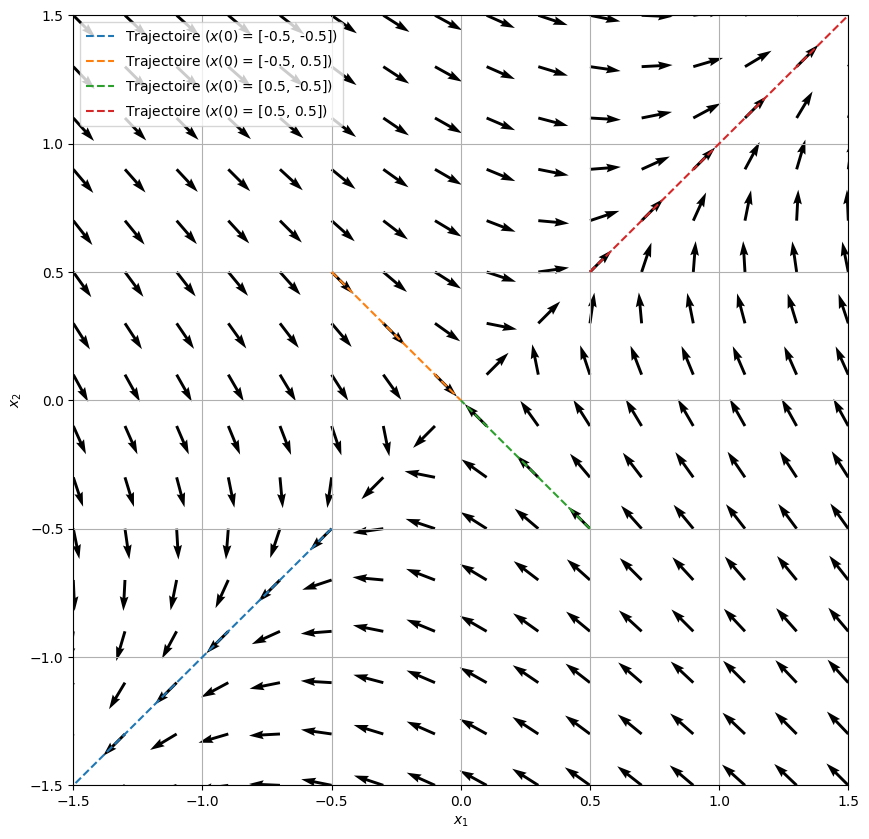

In [26]:
T_MAX = 5.
A = np.array([[-1, 2], [2, -1]])
c_is = [[-0.5,-0.5], [-0.5,0.5], [0.5,-0.5], [0.5,0.5]]

plt.figure(figsize=(10, 10))
for c_i in c_is:
    true_trajectory_A(A, (0, T_MAX), c_i)

true_phase_portrait_A(A)

In [7]:
class TransitionPINN_A(nn.Module):
    def __init__(self, layer_size=32):
        super().__init__()
        self.l1 = nn.Linear(4, layer_size)
        self.l2 = nn.Linear(layer_size, layer_size)
        self.l3 = nn.Linear(layer_size, layer_size)
        self.l6 = nn.Linear(layer_size, 2)
        self.activation = nn.Tanh()

    def forward(self, t, t0, x1_0, x2_0):
        inputs = torch.concatenate([t, t0, x1_0, x2_0], axis=-1)
        x = self.activation(self.l1(inputs))
        x = self.activation(self.l2(x))
        x = self.activation(self.l3(x))
        return (t-t0) * self.l6(x) + torch.concatenate([x1_0, x2_0], axis=-1)

def loss_physics_A(model, t, t0, x1_0, x2_0):
    x1x2 = model(t, t0, x1_0, x2_0)
    x1, x2 = x1x2[:, 0:1], x1x2[:, 1:2]
    dx1_dt = torch.autograd.grad(x1, t, grad_outputs=torch.ones_like(t), create_graph=True)[0]
    dx2_dt = torch.autograd.grad(x2, t, grad_outputs=torch.ones_like(t), create_graph=True)[0]
    loss_x1 = ((dx1_dt - (A[0,0]*x1 + A[0,1]*x2))**2).mean()
    loss_x2 = ((dx2_dt - (A[1,0]*x1 + A[1,1]*x2))**2).mean()
    return loss_x1 + loss_x2

In [18]:
n_points = 1000
n_epochs = 5000

torch.random.manual_seed(0)
model_A = TransitionPINN_A()
optimizer = optim.Adam(model_A.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=200, min_lr=1e-5)

for _ in (pbar:=tqdm(range(n_epochs))):
    optimizer.zero_grad()
    t0 = torch.rand((n_points, 1), requires_grad=True) * T_MAX
    t = t0 + torch.rand((n_points, 1), requires_grad=True) * (T_MAX-t0)
    x1_0 = (torch.rand((n_points, 1), requires_grad=True)-0.5) * 8.
    x2_0 = (torch.rand((n_points, 1), requires_grad=True)-0.5) * 8.
    loss = loss_physics_A(model_A, t, t0, x1_0, x2_0)
    loss.backward()
    optimizer.step()
    scheduler.step(loss.item())
    pbar.set_description(f"Loss: {loss.item():.4e}")

  0%|          | 0/50000 [00:00<?, ?it/s]

In [19]:
def model_trajectory(model, interval: list[int], c_i: list[int]) -> None:
    t_eval = torch.linspace(interval[0], interval[1], 250).unsqueeze(-1)
    x1x2 = model(t_eval, torch.zeros_like(t_eval), torch.ones_like(t_eval)*c_i[0], torch.ones_like(t_eval)*c_i[1]).detach().cpu().squeeze().numpy()
    x1, x2 = x1x2[:, 0], x1x2[:, 1]
    plt.plot(x1, x2, label="Trajectoire ("+r"$x(0)$"+f" = {c_i})")
    plt.xlabel(r"$x_1$")
    plt.ylabel(r"$x_2$")
    plt.legend()

def model_phase_portrait(model, ax, t=1.,):
    x1_0, x2_0 = torch.meshgrid(torch.arange(-1.5, 1.6, 0.2), torch.arange(-1.5, 1.6, 0.2))
    x1_0 = x1_0.flatten().unsqueeze(-1)
    x2_0 = x2_0.flatten().unsqueeze(-1)
    t = torch.ones_like(x1_0, requires_grad=True)*t
    x1x2 = model(t, t.detach(), x1_0, x2_0)
    x1, x2 = x1x2[:, 0:1], x1x2[:, 1:2]
    x1_values = torch.autograd.grad(x1, t, grad_outputs=torch.ones_like(t), create_graph=True)[0].cpu().detach().squeeze().numpy()
    x2_values = torch.autograd.grad(x2, t, grad_outputs=torch.ones_like(t), create_graph=True)[0].cpu().detach().squeeze().numpy()

    norms = np.sqrt(x1_values**2 + x2_values**2)
    x1_normalized = x1_values / norms
    x2_normalized = x2_values / norms

    vector_scale = 25
    ax.quiver(x1_0.cpu().detach().squeeze(), x2_0.cpu().detach().squeeze(), x1_normalized, x2_normalized, scale=vector_scale, color='gray')
    ax.set_xlim([-1.5, 1.5])
    ax.set_ylim([-1.5, 1.5])
    ax.set_title(f"t: {t[0].item()}")

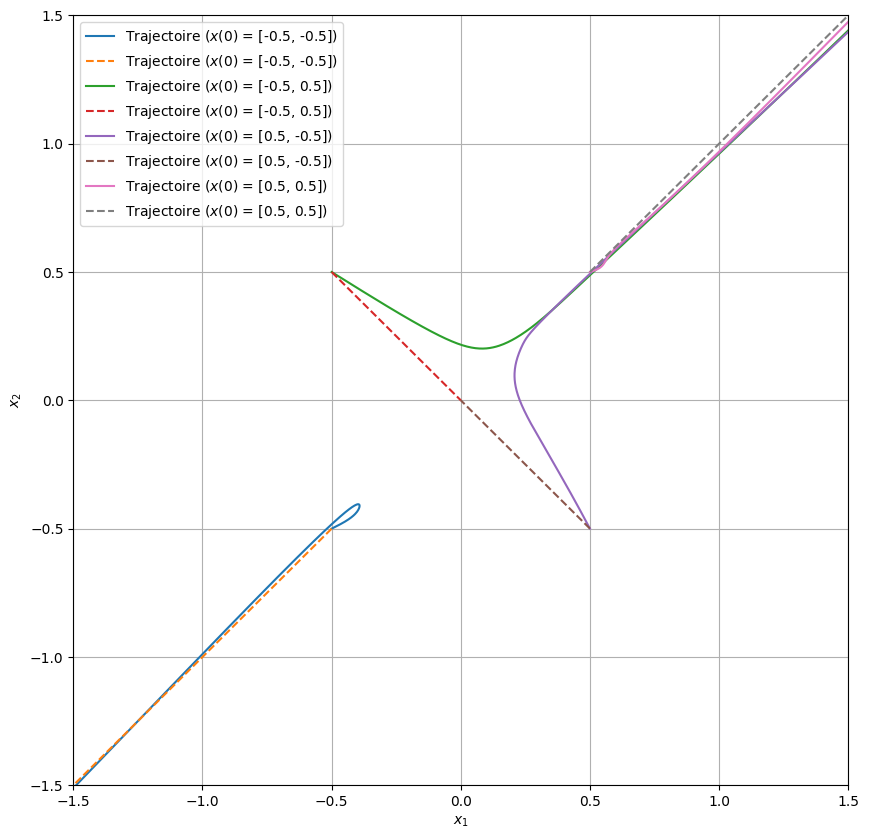

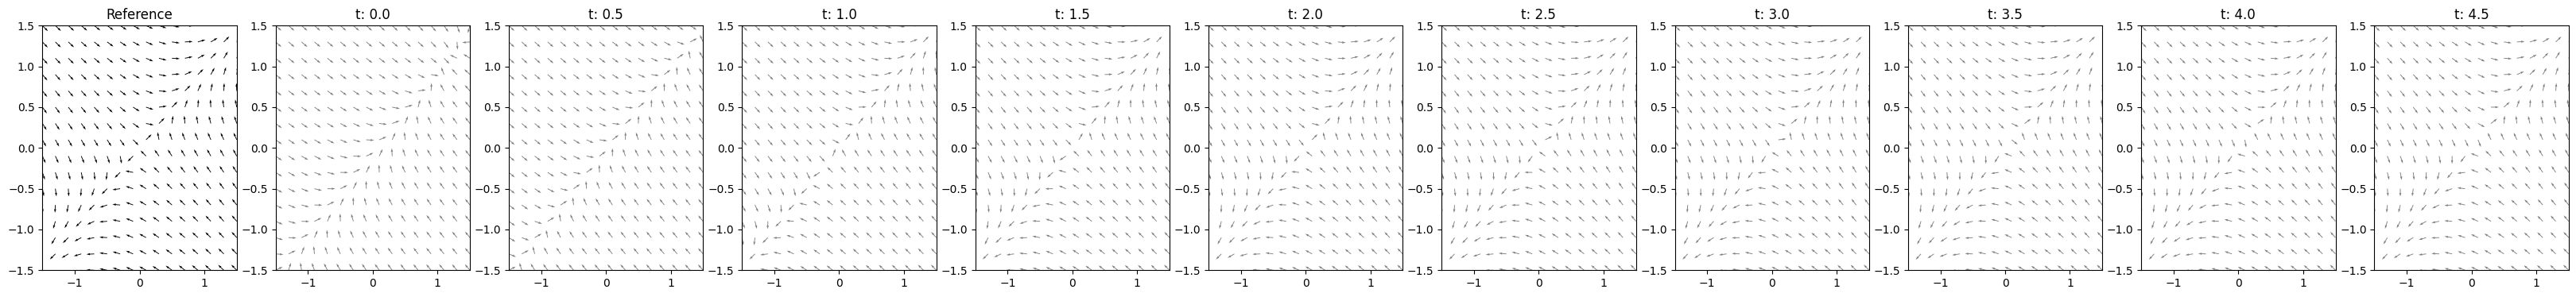

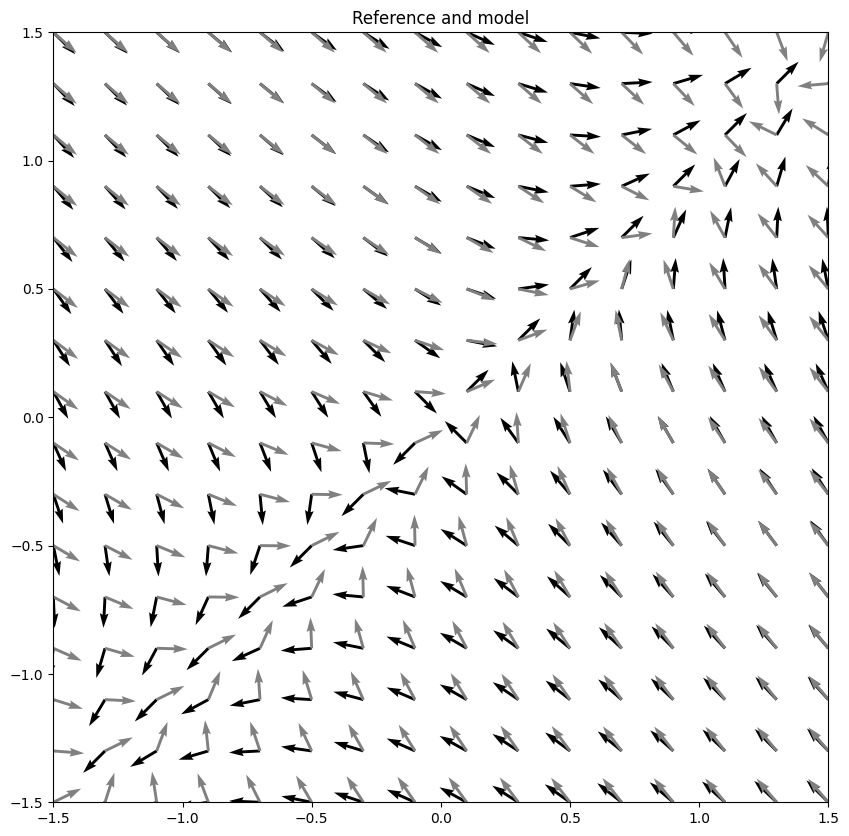

In [27]:
plt.figure(figsize=(10, 10))
for c_i in c_is:
    model_trajectory(model_A, (0, T_MAX), c_i)
    true_trajectory_A(A, (0, T_MAX), c_i)
plt.xlim(-1.5, 1.5)
plt.ylim(-1.5, 1.5)
plt.grid()
plt.savefig('trajectories_saddle_pinn.jpg')
plt.show()
fig, ax = plt.subplots(1, int(T_MAX*2)+1, figsize=(T_MAX*2*4 + 1, 4))
true_phase_portrait_A(A, ax[0])
for t in np.arange(0, T_MAX, .5):
    model_phase_portrait(model_A, ax[int(t*2)+1], t)
plt.savefig('phase_portrait_through_time_saddle_pinn.jpg')
plt.show()
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
true_phase_portrait_A(A, ax)
model_phase_portrait(model_A, ax, 0)
ax.set_title("Reference and model")
plt.savefig('phase_portrait_saddle_pinn.jpg')
plt.show()

- Consistency: $\phi(t, t, x(t)) = x$,
- Composition: $\phi(t_2, t_0, x(t_0)) = \phi(t_2, t_1, \phi(t_1, t_0, x(t_0)))$,
- Stationarity: $\phi(t, t_0, x(t_0)) = \phi(t+\delta t, t_0+\delta t, x(t_0))$.

In [21]:
class TransitionPINN_A2(nn.Module):
    def __init__(self, layer_size=32):
        super().__init__()
        self.l1 = nn.Linear(3, layer_size)
        self.l2 = nn.Linear(layer_size, layer_size)
        self.l3 = nn.Linear(layer_size, layer_size)
        self.l6 = nn.Linear(layer_size, 2)
        self.activation = nn.Tanh()

    def forward(self, t, t0, x1_0, x2_0):
        tau = t - t0
        inputs = torch.concatenate([tau, x1_0, x2_0], axis=-1)
        x = self.activation(self.l1(inputs))
        x = self.activation(self.l2(x))
        x = self.activation(self.l3(x))
        return tau * self.l6(x) + torch.concatenate([x1_0, x2_0], axis=-1)

In [22]:
def consistency_loss(model, t0, x1_0, x2_0):
    x1x2 = model(t0, t0, x1_0, x2_0)
    return ((x1x2-torch.concatenate([x1_0, x2_0], axis=-1))**2).mean()

def composition_loss(model, t, t0, t1, x1_0, x2_0):
    x1 = model(t, t0, x1_0, x2_0)
    x1x2_1 = model(t1, t0, x1_0, x2_0)
    x1_1, x2_1 = x1x2_1[:, 0:1].detach(), x1x2_1[:, 1:2].detach()
    x2 = model(t, t1, x1_1, x2_1)
    return ((x2-x1)**2).mean()

def stationarity_loss(model, t, t0, x1_0, x2_0, dt):
    x1x2 = model(t, t0, x1_0, x2_0)
    x1x2_dt = model(t+dt, t0+dt, x1_0, x2_0)
    return ((x1x2-x1x2_dt)**2).mean()

def derivative_stationarity_loss(model, t, t0, x1_0, x2_0, dt):
    x1x2 = model(t, t0, x1_0, x2_0)
    x1, x2 = x1x2[:, 0:1], x1x2[:, 1:2]
    x1x2_dt = model(t+dt, t0+dt, x1_0, x2_0)
    x1_dt, x2_dt = x1x2_dt[:, 0:1], x1x2_dt[:, 1:2]
    dx1 = torch.autograd.grad(x1, t, grad_outputs=torch.ones_like(t), create_graph=True)[0]
    dx1dt = torch.autograd.grad(x1_dt, t, grad_outputs=torch.ones_like(t), create_graph=True)[0]
    dx2 = torch.autograd.grad(x2, t, grad_outputs=torch.ones_like(t), create_graph=True)[0]
    dx2dt = torch.autograd.grad(x2_dt, t, grad_outputs=torch.ones_like(t), create_graph=True)[0]
    return ((dx1-dx1dt)**2).mean() + ((dx2-dx2dt)**2).mean()

In [ ]:
from pcgrad import PCGrad

n_points = 1000
n_epochs = 5000

torch.random.manual_seed(0)
model_A2 = TransitionPINN_A2()
op = optim.Adam(model_A2.parameters(), lr=1e-3)
optimizer = PCGrad(op)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(op, patience=200, min_lr=1e-5)

for _ in (pbar:=tqdm(range(n_epochs))):
    optimizer.zero_grad()
    t0 = torch.rand((n_points, 1), requires_grad=True) * T_MAX
    t1 = t0 + torch.rand((n_points, 1), requires_grad=True) * (T_MAX-t0)
    t = t1 + torch.rand((n_points, 1), requires_grad=True) * (T_MAX-t1)
    x1_0 = (torch.rand((n_points, 1), requires_grad=True)-0.5) * 8.
    x2_0 = (torch.rand((n_points, 1), requires_grad=True)-0.5) * 8.
    dt = (torch.rand((n_points, 1)))
    loss1 = loss_physics_A(model_A2, t, t0, x1_0, x2_0)
    loss2 = consistency_loss(model_A2, t0, x1_0, x2_0)
    loss3 = composition_loss(model_A2, t, t0, t1, x1_0, x2_0)
    loss4 = stationarity_loss(model_A2, t, t0, x1_0, x2_0, dt)
    loss5 = derivative_stationarity_loss(model_A2, t, t0, x1_0, x2_0, dt)
    losses = [loss1,loss3]#,loss4,loss5]
    optimizer.pc_backward(losses)
    optimizer.step()
    scheduler.step(sum(losses).item())
    pbar.set_description(f"Loss Physics: {loss1.item():.4e}, Loss Consistency: {loss2.item():.4e}, Loss Composition: {loss3.item():.4e}, Loss Stationarity: {loss4.item():.4e}, , dLoss Stationarity: {loss5.item():.4e}")

  0%|          | 0/5000 [00:00<?, ?it/s]

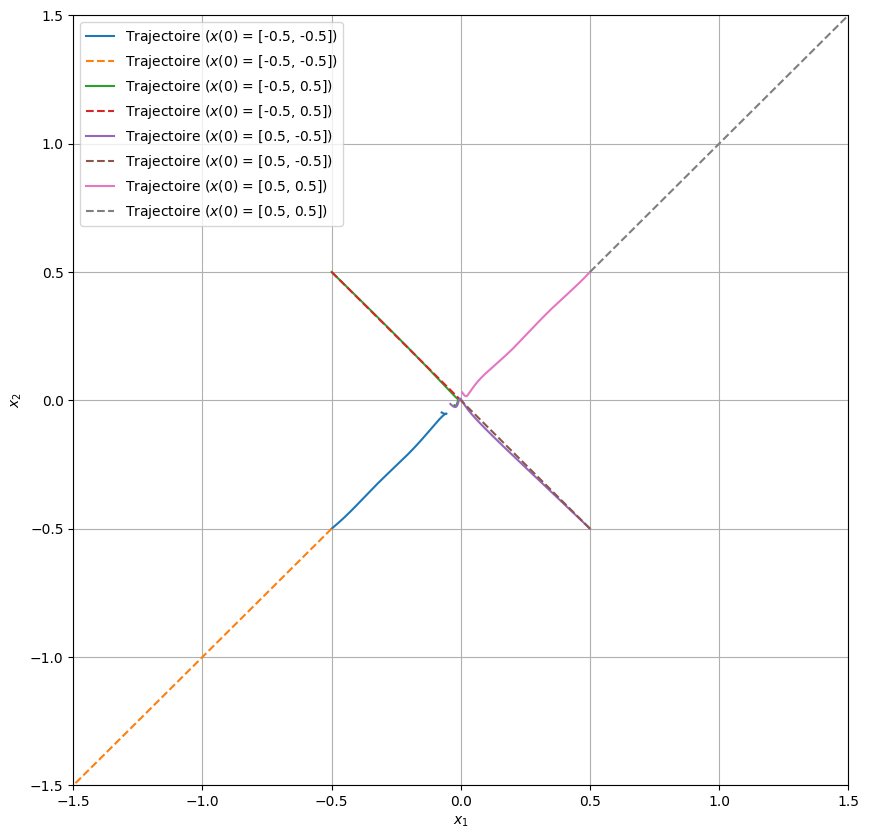

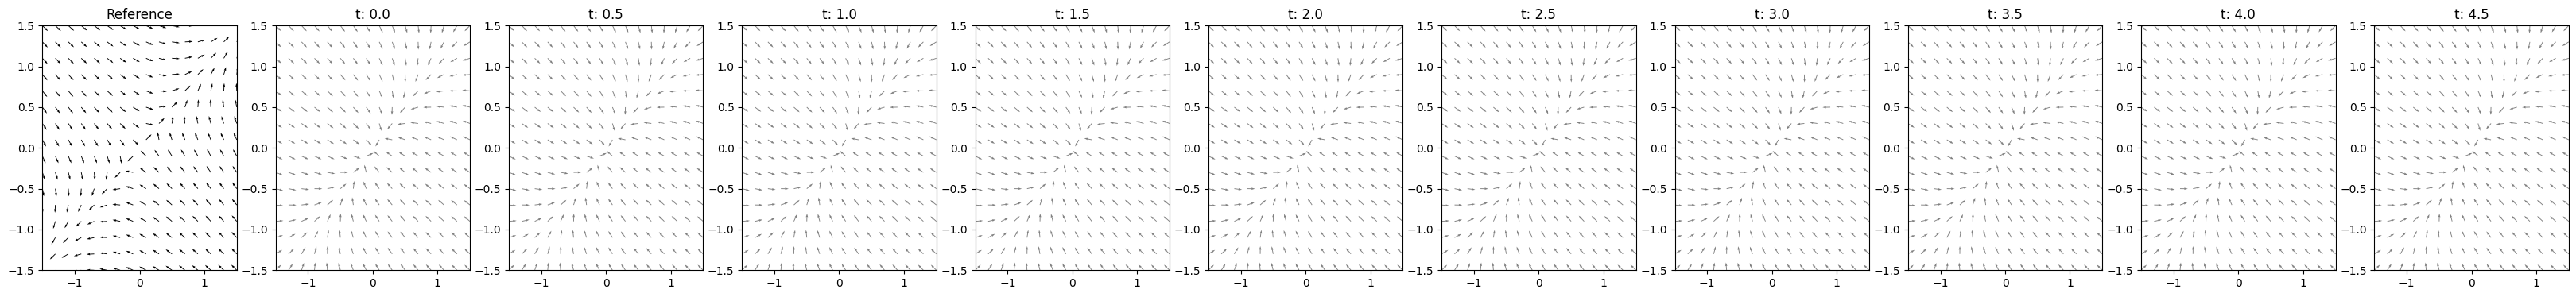

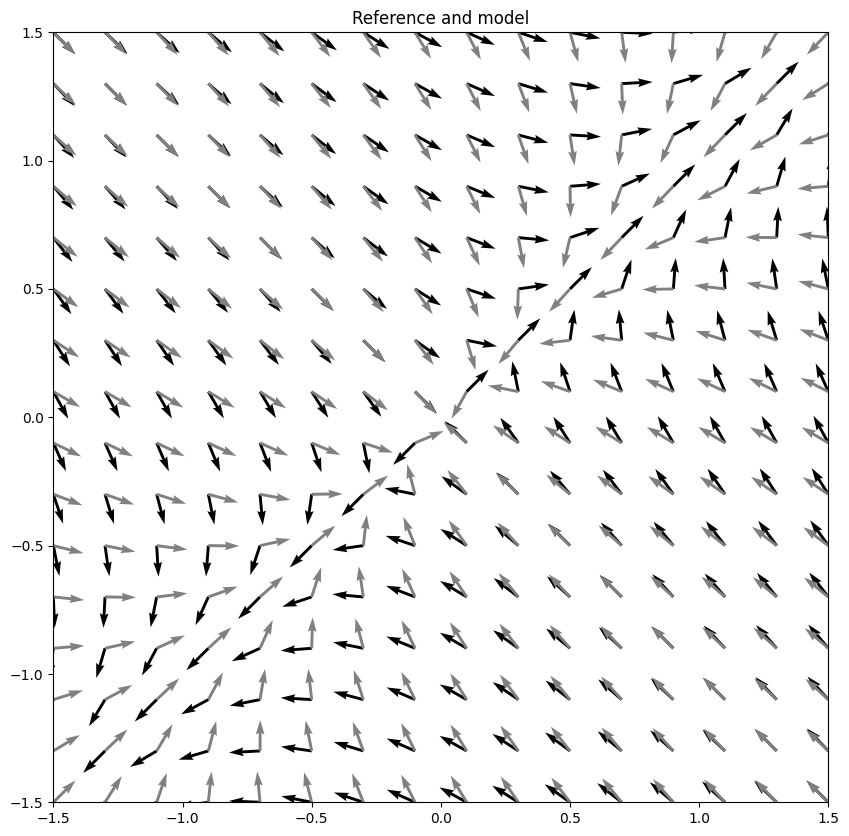

In [28]:
plt.figure(figsize=(10, 10))
for c_i in c_is:
    model_trajectory(model_A2, (0, T_MAX), c_i)
    true_trajectory_A(A, (0, T_MAX), c_i)
plt.xlim(-1.5, 1.5)
plt.ylim(-1.5, 1.5)
plt.grid()
plt.savefig('trajectories_saddle_pinn2.jpg')
plt.show()
fig, ax = plt.subplots(1, int(T_MAX*2)+1, figsize=(T_MAX*2*4 + 1, 4))
true_phase_portrait_A(A, ax[0])
for t in np.arange(0, T_MAX, .5):
    model_phase_portrait(model_A2, ax[int(t*2)+1], t)
plt.savefig('phase_portrait_through_time_saddle_pinn2.jpg')
plt.show()
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
true_phase_portrait_A(A, ax)
model_phase_portrait(model_A2, ax, 0)
ax.set_title("Reference and model")
plt.savefig('phase_portrait_saddle_pinn2.jpg')
plt.show()